In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,bestech park view aindependentda,sector 81,4.35,7937.0,5481.0,Plot area 5480(509.11 sq.m.),4,4,3,...,NaN,5480.0,NaN,0,1,1,0,0,0,51
1,flat,signature global solera,sector 107,0.28,5674.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,...,NaN,NaN,489.0,0,0,0,0,0,0,45
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.),5,5,3,...,NaN,350.0,NaN,0,0,0,0,0,1,22
3,flat,hcbs sports ville,sohna road,0.29,5587.0,519.0,Carpet area: 519 (48.22 sq.m.),2,2,1,...,NaN,NaN,519.0,0,0,0,0,0,0,44
4,flat,orchid petals,sector 49,2.55,12318.0,2070.0,Super Built up area 2070(192.31 sq.m.)Built Up...,3,4,3,...,2070.0,2060.0,1760.0,1,0,0,0,0,1,49


In [4]:
df.shape

(3803, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  super_built_up_area  1915 non-null   float64
 14  built_up_area        1733 non-null   float64
 15  carpet_area          1944 non-null   f

In [6]:
df.duplicated().sum()

np.int64(126)

In [7]:
df.drop_duplicates(inplace=True)

# 1. *`property_type`*

<Axes: xlabel='property_type'>

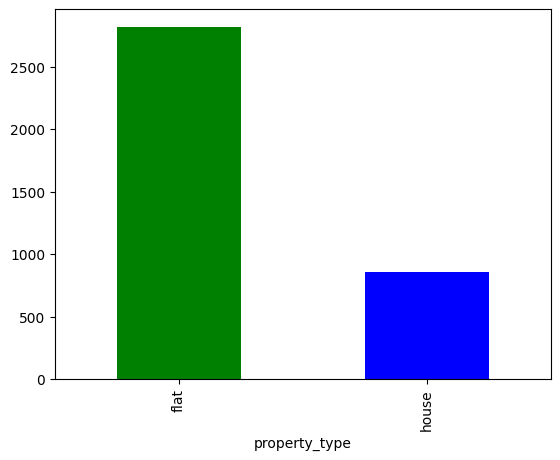

In [15]:
df['property_type'].value_counts().plot(kind='bar',color=['green','blue'])

In [17]:
df['property_type'].value_counts(normalize=True)*100

,proportion
property_type,
flat,76.638564
house,23.361436


Observations

1. Flats are in majority(76.64 percent) and there are less number of houses(23.36 percent)

2. No missing value

# `2.  society `





In [19]:
df['society'].value_counts().shape

(676,)

In [20]:
df['society'].value_counts()

,count
society,
independent,486
tulip violet,75
ss the leaf,73
shapoorji pallonji joyville gurugram,42
dlf new town heights,42
...,...
aipl joy square,1
chanderlok society,1
project krishna colony,1


In [28]:
df['society'].value_counts(normalize=True)*100

,proportion
society,
independent,13.220892
tulip violet,2.040261
ss the leaf,1.985854
shapoorji pallonji joyville gurugram,1.142546
dlf new town heights,1.142546
...,...
aipl joy square,0.027203
chanderlok society,0.027203
project krishna colony,0.027203


In [21]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

,proportion
society,
tulip violet,0.023511
ss the leaf,0.046395
shapoorji pallonji joyville gurugram,0.059561
dlf new town heights,0.072727
signature global park,0.083699
...,...
the close north,0.490282
ramsons kshitij,0.494357
umang monsoon breeze,0.498433


In [49]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins


{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(273),
 'Very Low (1)': np.int64(308)}

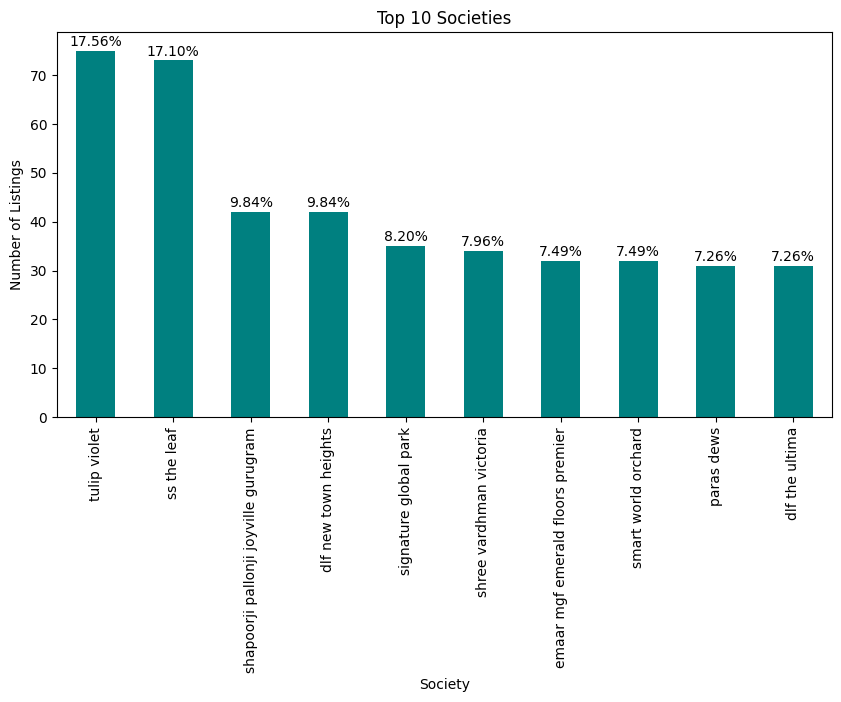

In [37]:
top_societies = df[df['society'] != 'independent']['society'].value_counts().head(10)
percentages = (top_societies / top_societies.sum()) * 100

ax = top_societies.plot(kind='bar', color='teal', figsize=(10,5))

for i, (count, pct) in enumerate(zip(top_societies, percentages)):
    ax.text(i, count + 1, f'{pct:.2f}%', ha='center')

plt.title('Top 10 Societies')
plt.xlabel('Society')
plt.ylabel('Number of Listings')

plt.show()

In [38]:
df['society'].isnull().sum()

np.int64(1)

In [39]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1863,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


**Observations**

Around 13% properties comes under independent tag.

There are 675 societies.

The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies

* Very High (>100): Only 1 society has more than 100 listings.

* High (50-100): 2 societies have between 50 to 100 listings.

* Average (10-49): 92 societies fall in this range with 10 to 49 listings each.

* Low (2-9): 273 societies have between 2 to 9 listings.
* Very Low (1): A significant number, 308 societies, have only 1 listing.

1 missing value

# **`3.sector`**

In [50]:
# unique sectors
df['sector'].value_counts().shape

(112,)

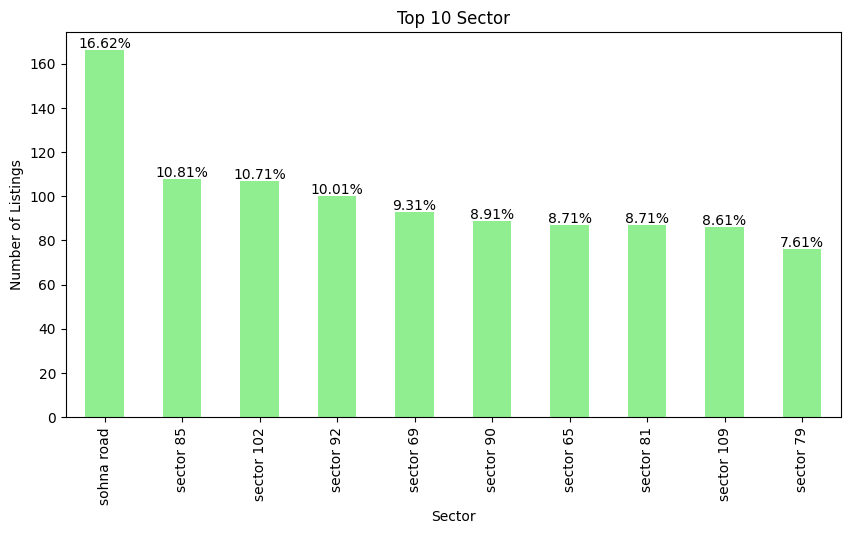

In [56]:
top_sector = df['sector'].value_counts().head(10)
percentages = (top_sector / top_sector.sum()) * 100

ax = top_sector.plot(kind='bar', color='lightgreen', figsize=(10,5))

for i, (count, pct) in enumerate(zip(top_sector, percentages)):
    ax.text(i, count + 1, f'{pct:.2f}%', ha='center')

plt.title('Top 10 Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Listings')

plt.show()

In [53]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(62),
 'Low (2-9)': np.int64(21),
 'Very Low (1)': np.int64(1)}

**Observations**

There are a total of 112 unique sectors in the dataset.

Frequency distribution of sectors:

Very High (>100): 3 sectors have more than 100 listings.

High (50-100): 25 sectors have between 50 to 100 listings.

Average (10-49): A majority, 62 sectors, fall in this range with 10 to 49 listings each.

Low (2-9): 21 sectors have between 2 to 9 listings.

Very Low (1): 1 sector have only one time listings.

# ***`4. price`***

In [57]:
df['price'].isnull().sum()

np.int64(17)

In [58]:
df['price'].describe()

,price
count,3660.000000
mean,2.533664
std,2.980623
min,0.070000
25%,0.950000
50%,1.520000
75%,2.750000
max,31.500000


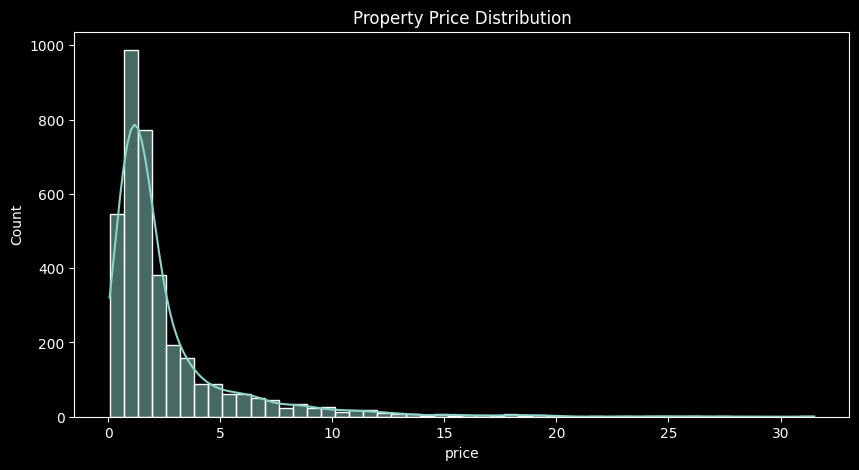

In [71]:
plt.style.use('dark_background')
plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Property Price Distribution')
plt.show()

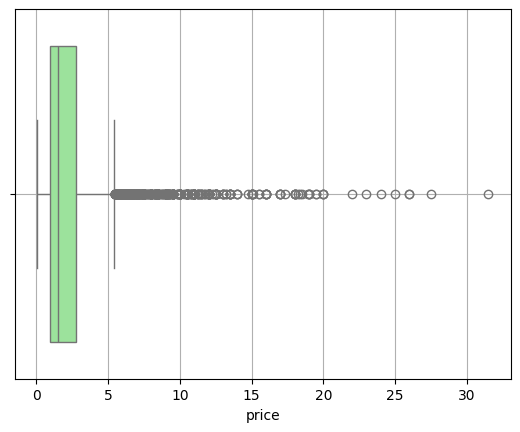

In [68]:
plt.style.use('default')
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

**Descriptive Statistics:**

Count: There are 3,660 non-missing price entries.

Mean Price: The average price is approximately 2.53 crores.

Median Price: The median (or 50th percentile) price is 1.52 crores.

Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.

Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.

IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.

**Visualizations:**

Distribution:
   The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.

Box Plot:
  The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
  
Missing Values: There are 17 missing values in the price column.

In [72]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.279170473313463 14.933372629214258


Skewness: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

Kurtosis: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [73]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

,price
0.01,0.250
0.05,0.370
0.95,8.500
0.99,15.264


Quantile Analysis:

1% Quantile: Only 1% of properties are priced below 0.25 crores.

5% Quantile: 5% of properties are priced below 0.37 crores.

95% Quantile: 95% of properties are priced below 8.5 crores.

99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [74]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.8)

In [75]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [76]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [77]:
outliers['price'].describe()

,price
count,425.000000
mean,9.235624
std,4.065259
min,5.460000
25%,6.460000
50%,8.000000
75%,10.750000
max,31.500000


**Outliers Analysis (using IQR method):**

Based on the IQR method, there are 425 properties considered as outliers.

These outliers have an average price of approximately 9.24 crores.

The range for these outliers is from 5.46 crores to 31.5 crores.

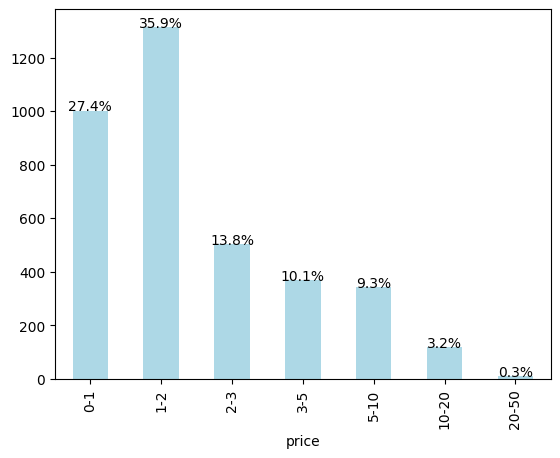

In [91]:
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
price_bins = pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index()

ax = price_bins.plot(kind='bar', color='lightblue')

for i, v in enumerate(price_bins):
    ax.text(i, v, f'{v/price_bins.sum()*100:.1f}%', ha='center')

plt.show()

The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.

There's a significant drop in the number of properties priced above "5 crores."

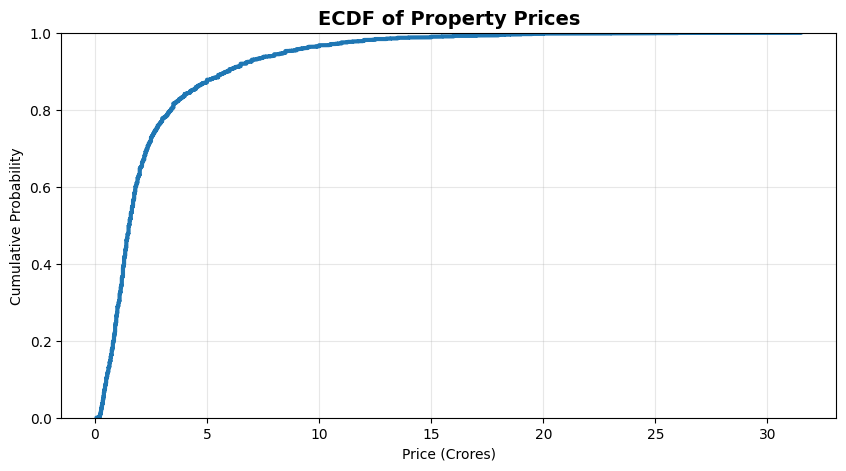

In [94]:
# ecdf plot
plt.figure(figsize=(10,5))

sns.ecdfplot(data=df, x='price', linewidth=3)

plt.title('ECDF of Property Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price (Crores)')
plt.ylabel('Cumulative Probability')
plt.grid(alpha=0.3)

plt.show()

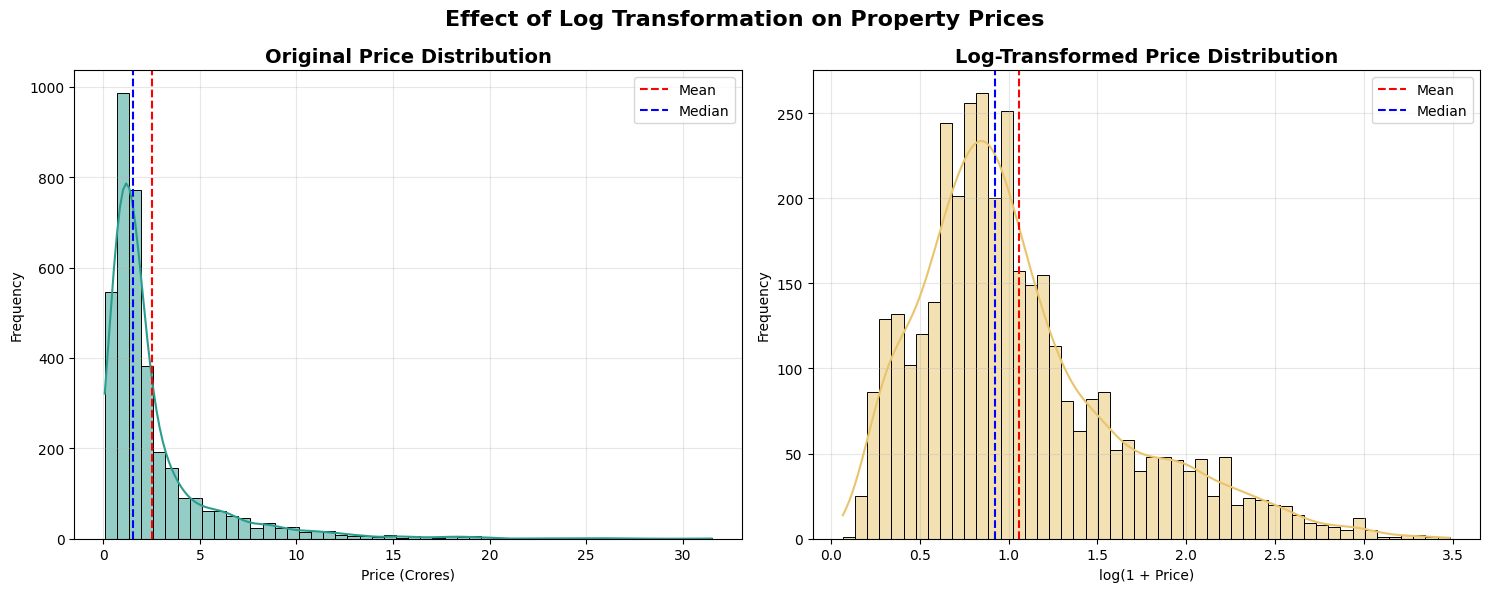

In [104]:
plt.figure(figsize=(15,6))

# Original Distribution
plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True, bins=50,
             color='#2A9D8F', edgecolor='black')

plt.axvline(df['price'].mean(), color='red',
            linestyle='--', label='Mean')
plt.axvline(df['price'].median(), color='blue',
            linestyle='--', label='Median')

plt.title('Original Price Distribution',
          fontsize=14, fontweight='bold')
plt.xlabel('Price (Crores)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

# Log Transformed Distribution
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50,
             color='#E9C46A', edgecolor='black')

plt.axvline(np.log1p(df['price']).mean(), color='red',
            linestyle='--', label='Mean')
plt.axvline(np.log1p(df['price']).median(), color='blue',
            linestyle='--', label='Median')

plt.title('Log-Transformed Price Distribution',
          fontsize=14, fontweight='bold')
plt.xlabel('log(1 + Price)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle('Effect of Log Transformation on Property Prices',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [99]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255315 0.9646692415449274


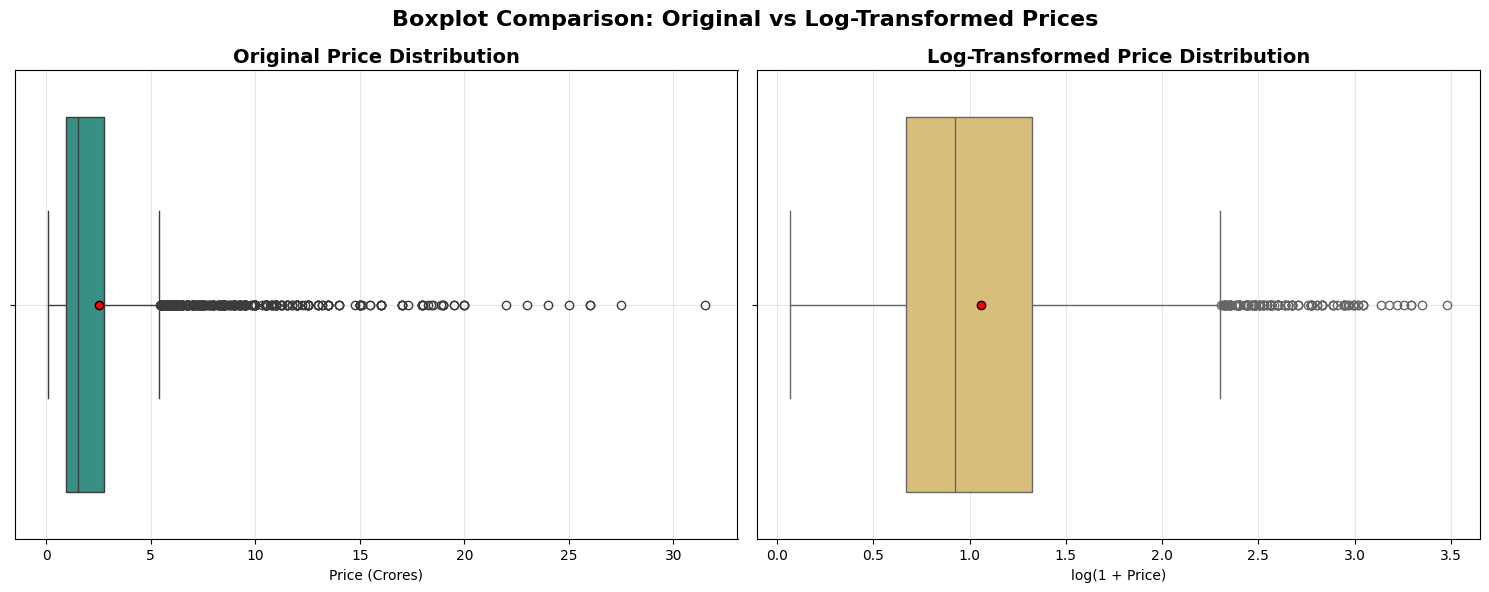

In [103]:
plt.figure(figsize=(15,6))

# Original Price
plt.subplot(1,2,1)
sns.boxplot(
    x=df['price'],
    color='#2A9D8F',
    showmeans=True,
    meanprops={
        'marker':'o',
        'markerfacecolor':'red',
        'markeredgecolor':'black'
    }
)

plt.title('Original Price Distribution',
          fontsize=14,
          fontweight='bold')
plt.xlabel('Price (Crores)')
plt.grid(alpha=0.3)

# Log Transformed Price
plt.subplot(1,2,2)
sns.boxplot(
    x=np.log1p(df['price']),
    color='#E9C46A',
    showmeans=True,
    meanprops={
        'marker':'o',
        'markerfacecolor':'red',
        'markeredgecolor':'black'
    }
)

plt.title('Log-Transformed Price Distribution',
          fontsize=14,
          fontweight='bold')
plt.xlabel('log(1 + Price)')
plt.grid(alpha=0.3)

plt.suptitle('Boxplot Comparison: Original vs Log-Transformed Prices',
             fontsize=16,
             fontweight='bold')

plt.tight_layout()
plt.show()

# **`5.price_per_sqft`**

In [105]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [106]:
df['price_per_sqft'].describe()

,price_per_sqft
count,3660.000000
mean,13892.668306
std,23210.067190
min,4.000000
25%,6817.250000
50%,9020.000000
75%,13880.500000
max,600000.000000


<Axes: xlabel='price_per_sqft', ylabel='Count'>

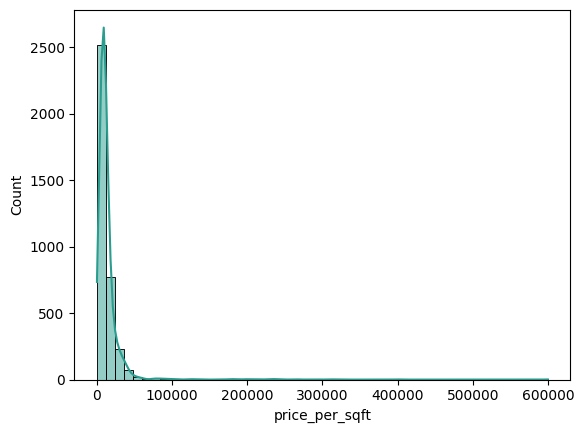

In [110]:
sns.histplot(df['price_per_sqft'], bins=50, color='#2A9D8F', kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: xlabel='price_per_sqft'>

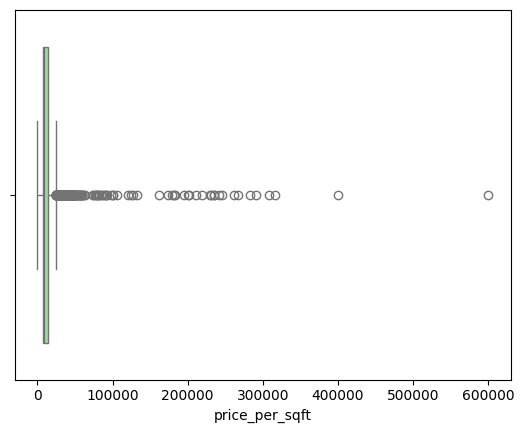

In [112]:
sns.boxplot(x=df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

Observations

* Potential Outliers
* Right Skewed
* 17 missing values

# ***`6.bedRoom`***

In [113]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

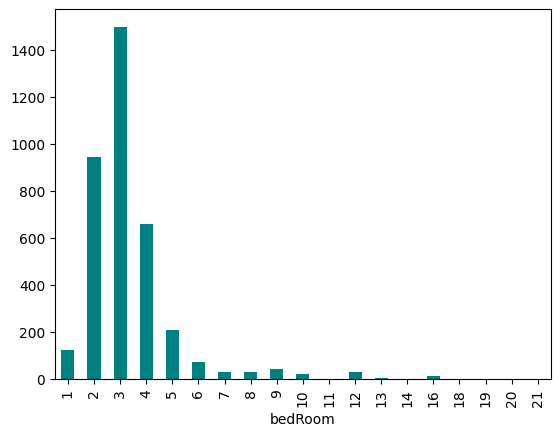

In [119]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar',color='teal')

<Axes: ylabel='proportion'>

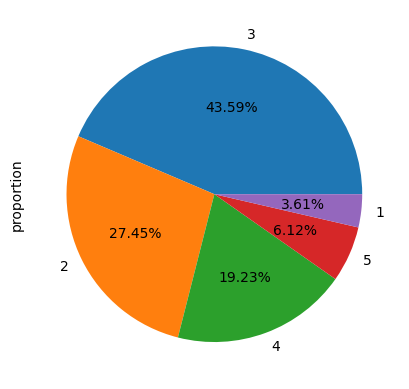

In [120]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# ***`7. bathroom`***

In [121]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

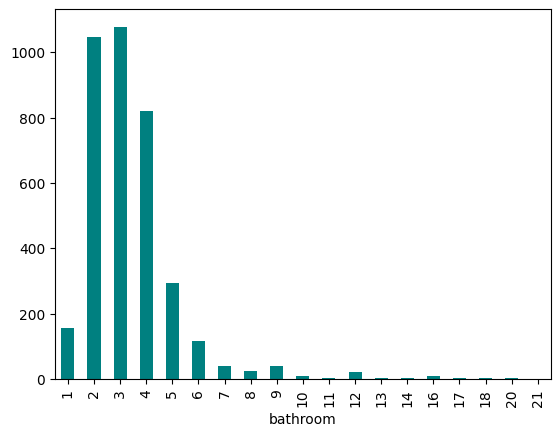

In [122]:
df['bathroom'].value_counts().sort_index().plot(kind='bar',color='teal')

<Axes: ylabel='proportion'>

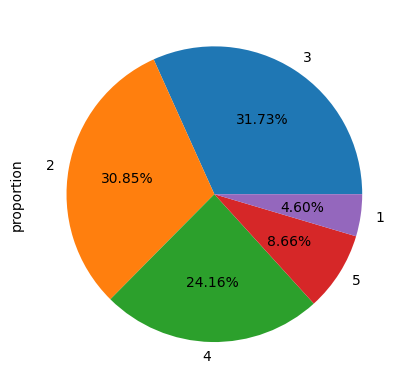

In [123]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# ***`8.balcony`***

In [125]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

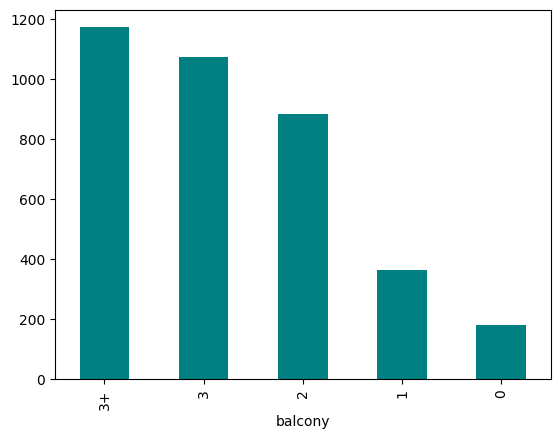

In [126]:
df['balcony'].value_counts().plot(kind='bar',color='teal')

<Axes: ylabel='proportion'>

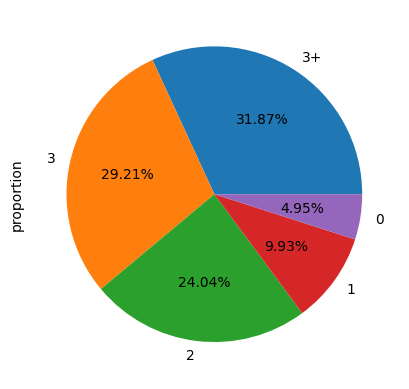

In [127]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

# ***`9.floornum`***

In [128]:
df['floorNum'].isnull().sum()

np.int64(19)

In [129]:
df['floorNum'].describe()

,floorNum
count,3658.000000
mean,6.798250
std,6.012454
min,0.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,51.000000


<Axes: xlabel='floorNum'>

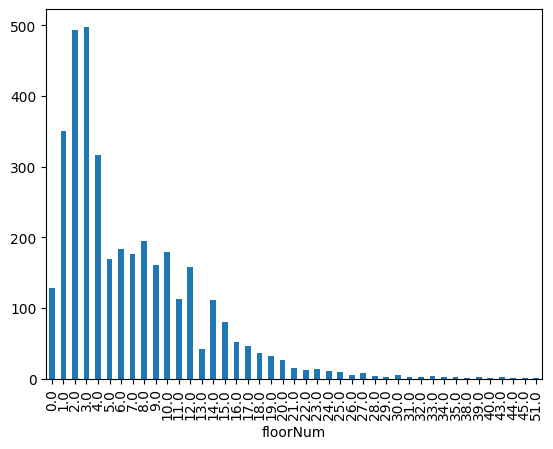

In [134]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

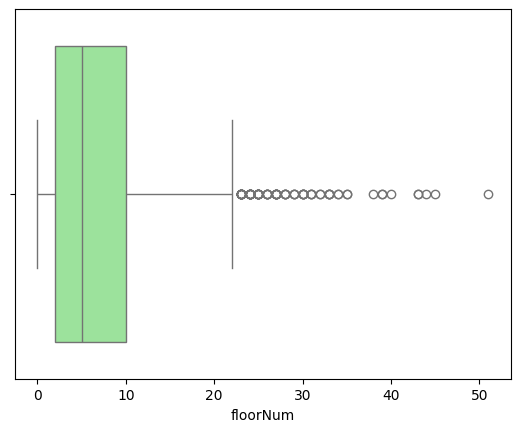

In [136]:
sns.boxplot(x=df['floorNum'], color='lightgreen')

The majority of the properties lie between the ground floor (0) and the 25th floor.

Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.

There are a few properties located at higher floors, but their frequency is much lower.

The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.

Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

# ***`10.facing`***

In [137]:
df['facing'].isnull().sum()

np.int64(1045)

In [138]:
df['facing'].fillna('NA',inplace=True)

/tmp/ipykernel_2146/3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [139]:
df['facing'].value_counts()

,count
facing,
NA,1045
North-East,623
East,623
North,387
West,249
South,231
North-West,193
South-East,173
South-West,153


# ***`11. age possession`***

In [140]:
df['agePossession'].isnull().sum()

np.int64(0)

In [141]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1646
New Property,593
Moderately Old,563
Undefined,306
Old Property,303
Under Construction,266


# ***`12.additional rooms`***

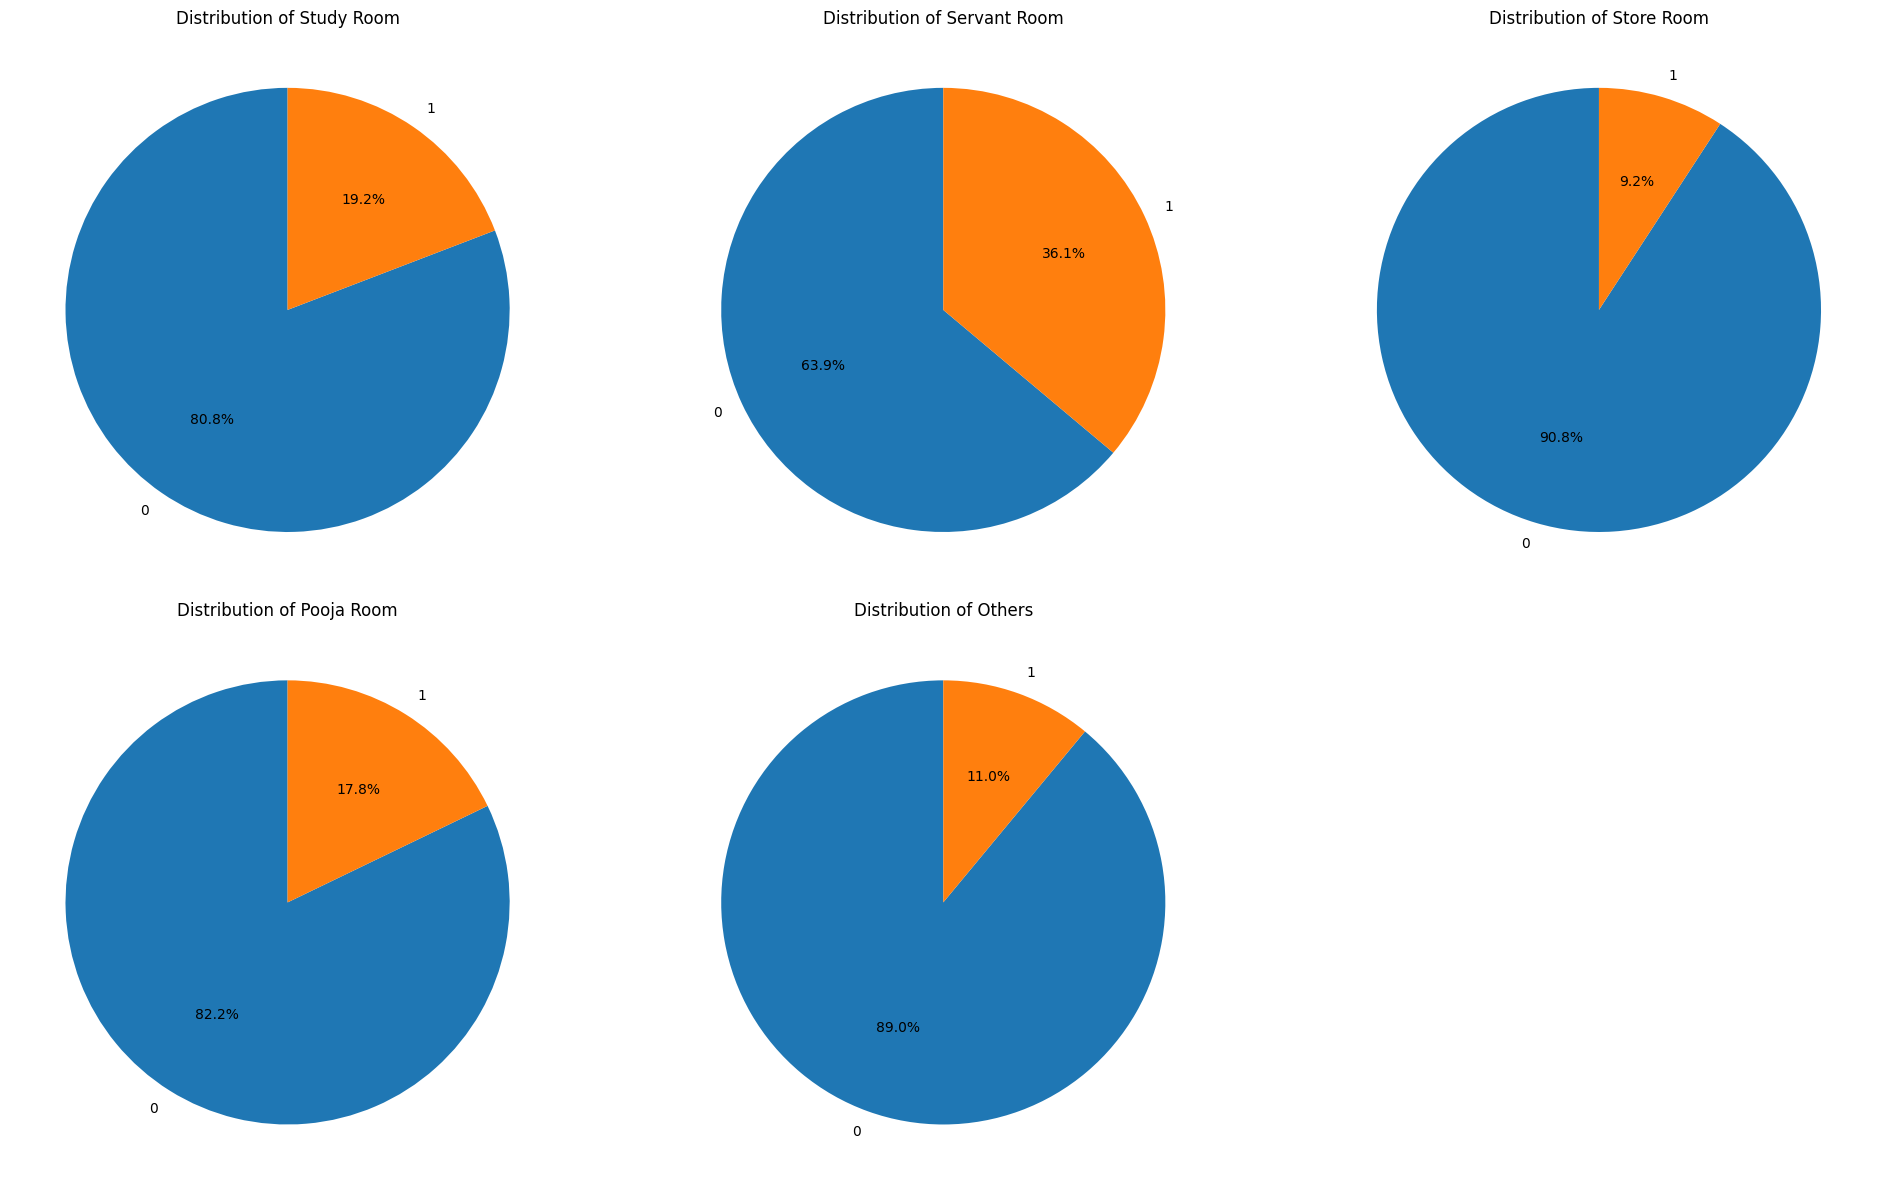

In [142]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# ***`13.furnishing_type`***

In [143]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
0,2436
1,1038
2,203


<Axes: ylabel='count'>

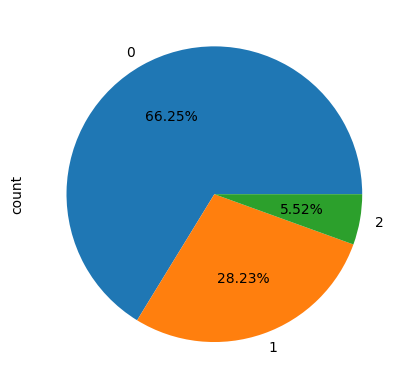

In [144]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

# ***`14.luxury score`***

In [145]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [146]:
df['luxury_score'].describe()

,luxury_score
count,3677.000000
mean,71.512918
std,53.059082
min,0.000000
25%,31.000000
50%,59.000000
75%,110.000000
max,174.000000


<Axes: xlabel='luxury_score', ylabel='Count'>

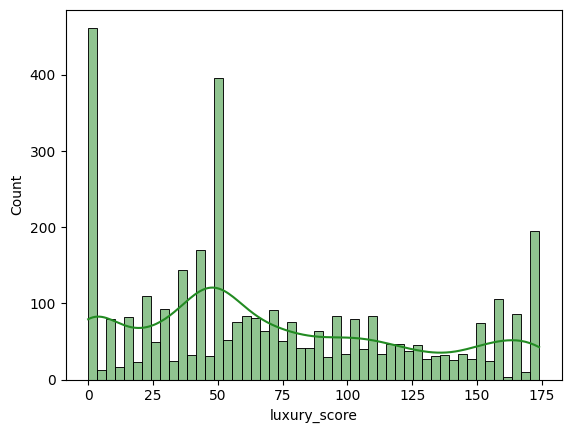

In [152]:
sns.histplot(df['luxury_score'], bins=50, color="#228B22", kde=True)

<Axes: xlabel='luxury_score'>

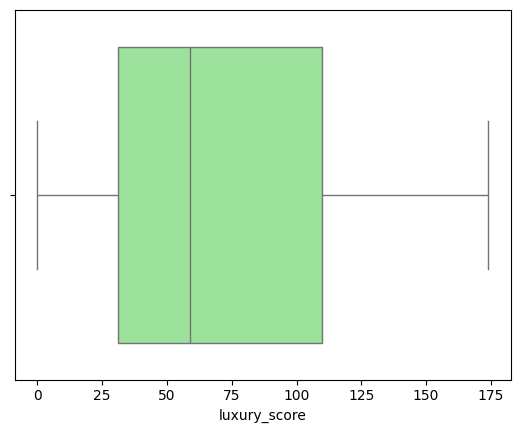

In [154]:
sns.boxplot(x=df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.


The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

# ***`15. area`***

## ***`15.1 super bilt up area`***

In [155]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1802)

In [156]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1875.000000
mean,1925.237627
std,764.172177
min,89.000000
25%,1479.500000
50%,1828.000000
75%,2215.000000
max,10000.000000


<Axes: xlabel='super_built_up_area', ylabel='Count'>

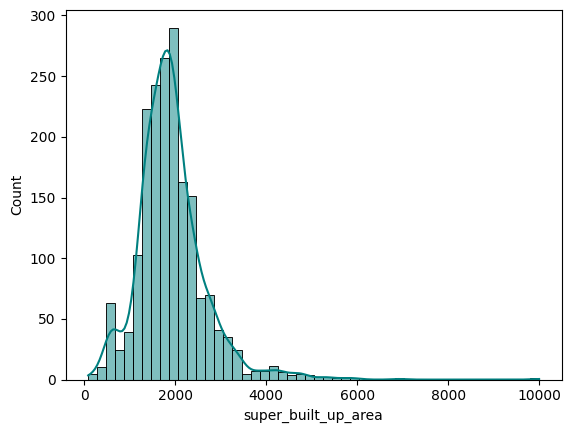

In [158]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='teal', kde=True)

<Axes: xlabel='super_built_up_area'>

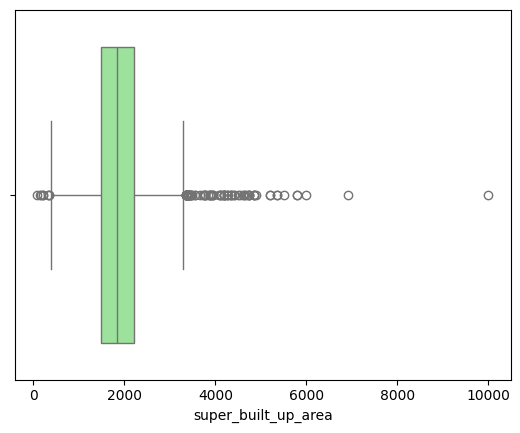

In [160]:
sns.boxplot(x=df['super_built_up_area'].dropna(), color='lightgreen')

Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.

There are a few properties with a significantly larger area, leading to a right-skewed distribution.

The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.

There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

## `15.2 bilt up area`

In [161]:
df['built_up_area'].isnull().sum()

np.int64(1987)

In [162]:
df['built_up_area'].describe()

,built_up_area
count,1690.000000
mean,2379.585816
std,17942.880237
min,2.000000
25%,1100.000000
50%,1650.000000
75%,2400.000000
max,737147.000000


<Axes: xlabel='built_up_area', ylabel='Count'>

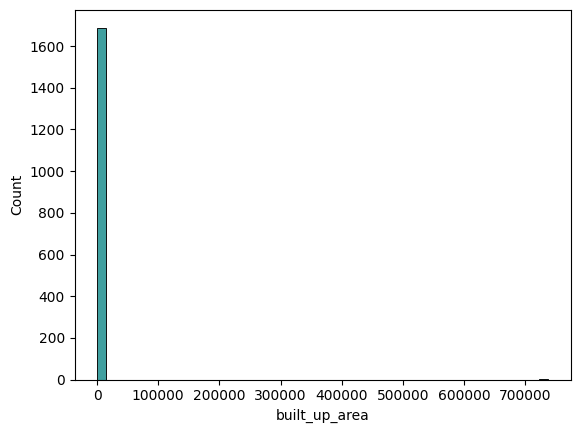

In [164]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='teal', kde=False)

<Axes: xlabel='built_up_area'>

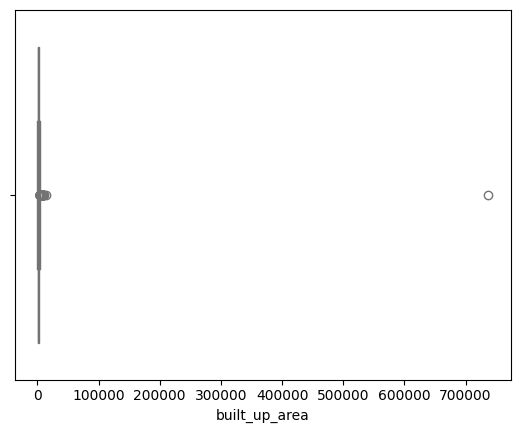

In [165]:
sns.boxplot(x=df['built_up_area'].dropna(), color='lightgreen')

Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.

There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.

The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.

The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

## ***`15.3 carpet area`***

In [166]:
df['carpet_area'].isnull().sum()

np.int64(1805)

In [167]:
df['carpet_area'].describe()

,carpet_area
count,1872.000000
mean,2529.179507
std,22799.836449
min,15.000000
25%,843.000000
50%,1300.000000
75%,1790.000000
max,607936.000000


<Axes: xlabel='carpet_area', ylabel='Count'>

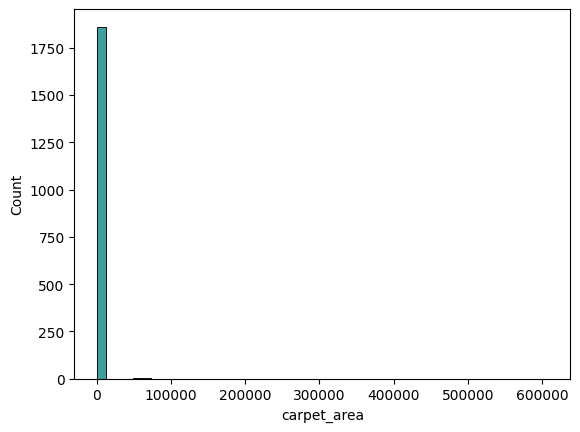

In [169]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='teal', kde=False)

<Axes: xlabel='carpet_area'>

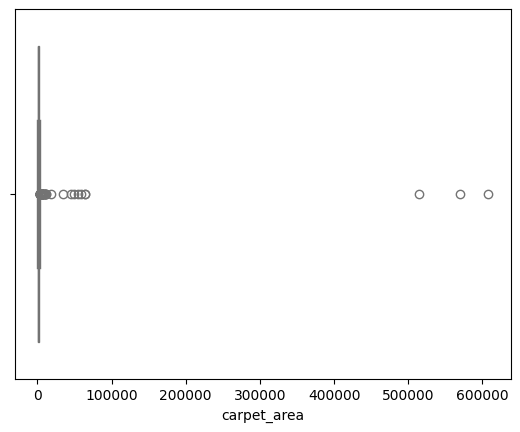

In [170]:
sns.boxplot(x=df['carpet_area'].dropna(), color='lightgreen')